📊 Loading and preparing data...
Original data shape: (8807, 12)
After cleaning: (8807, 16)
After feature engineering: (8807, 32)

🎯 Target Variable Distribution:
is_popular
0    6141
1    2666
Name: count, dtype: int64
Popularity rate: 0.303

🔧 Using 17 features:
  - is_movie
  - rating_encoded
  - duration_min
  - num_seasons
  - year_added
  - month_added
  - age
  - years_since_added
  - num_genres
  - num_countries
  - is_us
  - is_international
  - genre_dramas
  - genre_comedies
  - genre_action
  - genre_thrillers
  - genre_documentaries

📈 Data Split:
Training set: (7045, 17)
Test set: (1762, 17)

🤖 Training Models...

Training Random Forest...
Random Forest Results:
  Accuracy: 0.9058
  ROC-AUC: 0.9579
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      1229
           1       0.89      0.79      0.84       533

    accuracy                           0.91      1762
   macro avg       0.90      0.87      0.88      1762
weighte

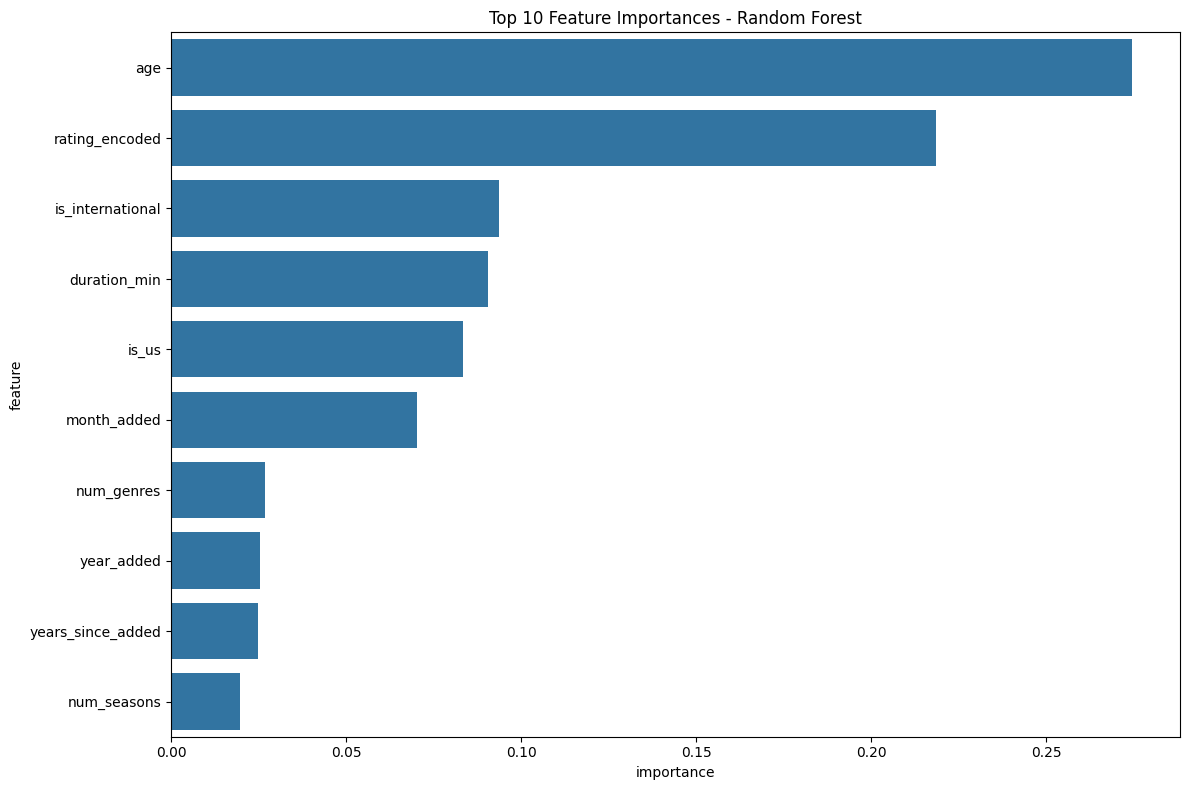


📊 Top 10 Most Important Features:
              feature  importance
6                 age    0.274500
1      rating_encoded    0.218552
11   is_international    0.093745
2        duration_min    0.090418
10              is_us    0.083502
5         month_added    0.070303
8          num_genres    0.026901
4          year_added    0.025241
7   years_since_added    0.024875
3         num_seasons    0.019629


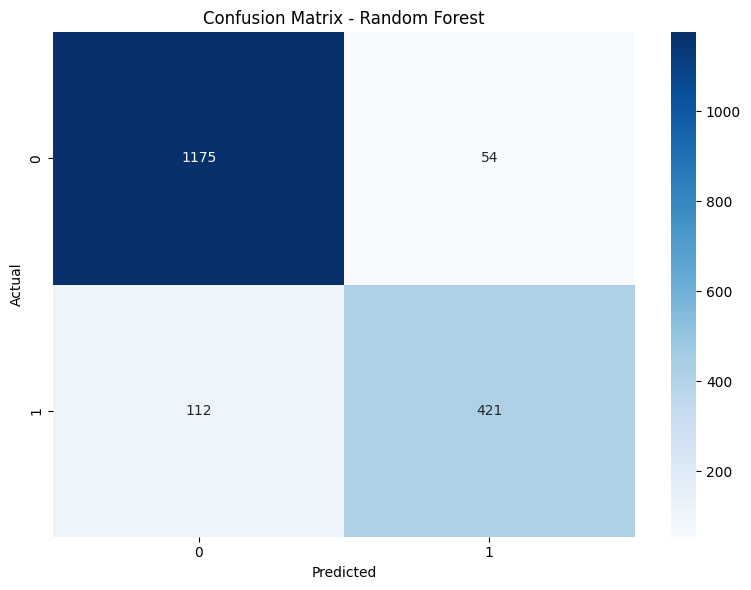


💾 Model artifacts saved successfully!

🧪 Testing with sample prediction...
Sample prediction: Popular
Confidence: 1.000

✅ Model training completed successfully!


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import our cleaning and feature engineering functions
import sys
sys.path.append('../src')
from data_clean import clean_netflix_data
from features import create_features

print("📊 Loading and preparing data...")

# Load data
df = pd.read_csv('../data/raw/netflix_titles.csv')
print(f"Original data shape: {df.shape}")

# Clean data
cleaned_df = clean_netflix_data(df)
print(f"After cleaning: {cleaned_df.shape}")

# Create features
featured_df = create_features(cleaned_df)
print(f"After feature engineering: {featured_df.shape}")

# Check target variable distribution
print("\n🎯 Target Variable Distribution:")
print(featured_df['is_popular'].value_counts())
print(f"Popularity rate: {featured_df['is_popular'].mean():.3f}")

# Define features for modeling
feature_columns = [
    'is_movie', 'rating_encoded', 'duration_min', 'num_seasons',
    'year_added', 'month_added', 'age', 'years_since_added',
    'num_genres', 'num_countries', 'is_us', 'is_international',
    'genre_dramas', 'genre_comedies', 'genre_action', 
    'genre_thrillers', 'genre_documentaries'
]

print(f"\n🔧 Using {len(feature_columns)} features:")
for feature in feature_columns:
    print(f"  - {feature}")

# Prepare X and y
X = featured_df[feature_columns].fillna(0)
y = featured_df['is_popular']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📈 Data Split:")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Train Multiple Models
print("\n🤖 Training Models...")

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"{name} Results:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")
    print(classification_report(y_test, y_pred))

# Select best model based on ROC-AUC
best_model_name = max(results.keys(), key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]['model']

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")

# Feature importance for Random Forest
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
    plt.title(f'Top 10 Feature Importances - {best_model_name}')
    plt.tight_layout()
    plt.savefig('../data/processed/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n📊 Top 10 Most Important Features:")
    print(feature_importance.head(10))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, results[best_model_name]['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Save the best model and artifacts
model_artifacts = {
    'model': best_model,
    'feature_columns': feature_columns,
    'feature_importance': feature_importance if 'feature_importance' in locals() else None,
    'model_name': best_model_name,
    'performance': {
        'accuracy': results[best_model_name]['accuracy'],
        'roc_auc': results[best_model_name]['roc_auc']
    }
}

joblib.dump(model_artifacts, '../data/processed/model_artifacts.pkl')
print("\n💾 Model artifacts saved successfully!")

# Test prediction with sample data
print("\n🧪 Testing with sample prediction...")
sample_data = X.iloc[0:1]  # First row
sample_pred = best_model.predict(sample_data)[0]
sample_prob = best_model.predict_proba(sample_data)[0][1]

print(f"Sample prediction: {'Popular' if sample_pred == 1 else 'Not Popular'}")
print(f"Confidence: {sample_prob:.3f}")

print("\n✅ Model training completed successfully!")